# GMSK AIS con NRZI -- generación, envío a la Red Pitaya y demodulación

In [ ]:
# ============================================================
# CELDA 0 — Imports y parametros
# ============================================================
import sys
import numpy as np
from math import log as ln

from gnuradio import gr, blocks, digital, analog

# ---------------- parametros de radio ----------------
FS      = 125e6                # tasa del DAC/ADC
fs_out  = 125e6 / 651           # tasa de salida del receptor (~192.012 ksps)
f_lo    = 10.7e6                # LO del receptor
OFFSET  = 0e3                   # offset de portadora sobre el LO
BAUD    = 9600.0                # AIS: 9600 bit/s
BT      = 0.4                   # AIS: BT nominal 0.4 (ITU-R M.1371)
L_PULSO = 4                     # duracion del pulso en simbolos

AMPLITUD = 4000
TX_BURST_SAMPLES = 32

NRZI_HABILITADO = True   # False para volver al comportamiento sin NRZI

SPS_TX = round(FS / BAUD)       # muestras/simbolo en el DAC (13021)
SPS_RX = fs_out / BAUD          # muestras/simbolo en el receptor (~20.0013)

PINC = round(f_lo / FS * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1

# ---------------- estructura de la ranura ----------------
# training  : 24 bits (todo ceros si NRZI, alternado 0101... si no)
# start flag: 01111110 (HDLC), igual que AIS
# datos     : 168 bits, el campo de datos de un mensaje AIS
# FCS       : CRC-16 (x^16 + x^12 + x^5 + 1) sobre los 168 bits de datos
# end flag  : 01111110
#
# Sin access code artificial ni bit stuffing todavia: se sincroniza como
# AIS de verdad, recuperando la fase de muestreo sin ningun patron
# conocido y delimitando la trama por el flag HDLC.
N_PREAMBULO = 24
START_FLAG  = '01111110'
N_PAYLOAD   = 168
N_FCS       = 16
N_RANURA    = (N_PREAMBULO + len(START_FLAG) +
               N_PAYLOAD + N_FCS + len(START_FLAG))   # 224 bits

print(f"NRZI_HABILITADO = {NRZI_HABILITADO}")
print(f"SPS_TX = {SPS_TX}   SPS_RX = {SPS_RX:.4f}")
print(f"Ranura: {N_PREAMBULO} training + {len(START_FLAG)} start flag + "
      f"{N_PAYLOAD} datos + {N_FCS} FCS + {len(START_FLAG)} end flag "
      f"= {N_RANURA} bits")
print(f"Duracion de la ranura: {N_RANURA/BAUD*1e3:.2f} ms")


NRZI_HABILITADO = True
SPS_TX = 13021   SPS_RX = 20.0013
Ranura: 24 training + 8 start flag + 168 datos + 16 FCS + 8 end flag = 224 bits
Duracion de la ranura: 23.33 ms


In [ ]:
# ============================================================
# CELDA 1 — Modulador: bloques reales de GNU Radio (gmskmod_bc) + NRZI
# ============================================================
# Cadena de bloques reales de GNU Radio:
#     vector_source_b -> map_bb([-1,1]) -> gmskmod_bc -> vector_sink_c
#
# La ranura se transmite en forma continua, como una estacion AIS que ocupa
# ranuras consecutivas: el buffer del DAC contiene exactamente una ranura y
# se repite en loop sin rampas ni silencios. Para que el empalme no meta un
# transitorio se toman dos precauciones:
#   1) se modulan 3 ranuras consecutivas (ya codificadas en NRZI si
#      corresponde) y se conserva la del medio;
#   2) se elige el payload de forma que la ranura, y su versión
#      codificada en NRZI, tengan una cantidad par de unos -- lo primero
#      para que el NRZI vuelva al mismo estado tras un periodo (haciendo
#      que tile+encode sea equivalente a encode+tile), lo segundo para
#      que la fase acumulada por periodo sea multiplo de 2*pi y el
#      buffer cierre en fase.


class TxGmsk(gr.top_block):
    """Corre gmskmod_bc sobre una lista de bits y devuelve el baseband
    complejo. El map_bb es necesario: gmskmod_bc espera simbolos +-1."""

    def __init__(self, bits, sps, L, bt):
        gr.top_block.__init__(self, "tx_gmsk")
        self.src  = blocks.vector_source_b(list(map(int, bits)), False)
        self.map  = digital.map_bb([-1, 1])
        self.mod  = digital.gmskmod_bc(int(sps), int(L), float(bt))
        self.sink = blocks.vector_sink_c()
        self.connect(self.src, self.map, self.mod, self.sink)

    def baseband(self):
        return np.array(self.sink.data(), dtype=np.complex64)


def crc16_ccitt(bits):
    """FCS de AIS/HDLC: CRC-16 con x^16 + x^12 + x^5 + 1, MSB primero."""
    reg = 0xFFFF
    for b in bits:
        reg ^= (int(b) & 1) << 15
        if reg & 0x8000:
            reg = ((reg << 1) & 0xFFFF) ^ 0x1021
        else:
            reg = (reg << 1) & 0xFFFF
    return reg


def nrzi_encode(bits, estado_inicial=1):
    """Codifica NRZI: mantiene el nivel si el bit es 1, lo invierte si es 0
    (convencion AIS/HDLC)."""
    bits = np.asarray(bits, dtype=np.uint8)
    out = np.empty_like(bits)
    estado = estado_inicial
    for i, b in enumerate(bits):
        if b == 0:
            estado ^= 1
        out[i] = estado
    return out


def nrzi_decode(bits, estado_inicial=1):
    """Inversa de nrzi_encode: bit logico = 1 si NO hubo transicion
    respecto del bit anterior, 0 si hubo transicion."""
    bits = np.asarray(bits, dtype=np.uint8)
    prev = np.concatenate(([estado_inicial], bits[:-1]))
    return (bits == prev).astype(np.uint8)


def construir_ranura(data):
    # Training: alternado 0101... da la maxima tasa de transicion en el
    # aire SIN NRZI. Con NRZI habilitado, una racha de CEROS logra lo
    # mismo despues de codificar.
    if NRZI_HABILITADO:
        training = [0] * N_PREAMBULO
    else:
        training = [i % 2 for i in range(N_PREAMBULO)]

    start_flag = [int(c) for c in START_FLAG]
    fcs_val    = crc16_ccitt(data)
    fcs        = [(fcs_val >> (15 - k)) & 1 for k in range(16)]
    end_flag   = [int(c) for c in START_FLAG]
    return training + start_flag + list(data) + fcs + end_flag


def generar_trama_bits(rng):
    """Sortea el campo de datos hasta que la ranura (y su version
    codificada en NRZI, si esta habilitado) tengan paridad par."""
    while True:
        data  = list(rng.randint(0, 2, N_PAYLOAD))
        trama = construir_ranura(data)
        if sum(trama) % 2 != 0:
            continue
        if NRZI_HABILITADO and int(np.sum(nrzi_encode(np.array(trama)))) % 2 != 0:
            continue
        break
    assert len(trama) == N_RANURA
    return trama, data


def construir_buffer_dac(bits_trama):
    """Modula la ranura, la sube a la portadora y la empaqueta para el DAC."""
    ns = len(bits_trama)

    bits_para_modular = np.tile(bits_trama, 3)
    if NRZI_HABILITADO:
        bits_para_modular = nrzi_encode(bits_para_modular)

    tb = TxGmsk(list(bits_para_modular), SPS_TX, L_PULSO, BT)
    tb.run()
    bb3 = tb.baseband().astype(np.complex128)
    k0  = ns * SPS_TX
    bb  = bb3[k0:k0 + ns * SPS_TX]

    N = (len(bb) // TX_BURST_SAMPLES) * TX_BURST_SAMPLES
    bb = bb[:N]

    fc = f_lo + OFFSET
    cycles = round(N * fc / FS)
    fc_adj = cycles * FS / N
    t = np.arange(N) / FS
    rf = np.real(bb * np.exp(1j * 2*np.pi * fc_adj * t))
    rf_i16 = (rf / np.max(np.abs(rf)) * AMPLITUD).astype(np.int16)
    words = (rf_i16.astype(np.int32) & 0x3FFF)
    return words, fc_adj, N, bb.astype(np.complex64)


rng = np.random.RandomState(2024)
bits_trama, payload_tx = generar_trama_bits(rng)
words_tx, fc_adj, N_buf, bb_ranura = construir_buffer_dac(bits_trama)
CFO_REAL = fc_adj - f_lo

# verificacion del cierre del loop: la desviacion de frecuencia en el
# empalme no debe superar la desviacion normal de la modulacion
_b2 = np.tile(bb_ranura.astype(np.complex128), 2)
_fi = np.angle(_b2[1:] * np.conj(_b2[:-1])) * FS / (2*np.pi)
print(f"Buffer TX: {N_buf} muestras ({N_buf//TX_BURST_SAMPLES} rafagas), "
      f"{N_buf/SPS_TX:.1f} simbolos")
print(f"fc = {fc_adj/1e6:.6f} MHz (offset {CFO_REAL/1e3:.3f} kHz sobre LO)")
print(f"Desviacion de pico: {np.max(np.abs(_fi)):.1f} Hz "
      f"(teorica {BAUD/4:.0f} Hz)  |  empalme del loop: "
      f"{abs(_fi[len(bb_ranura)-1]):.1f} Hz")
print(f"Rizado de envolvente: {np.ptp(np.abs(bb_ranura)):.2e}")


Buffer TX: 2916704 muestras (91147 rafagas), 224.0 simbolos
fc = 10.700006 MHz (offset 0.006 kHz sobre LO)
Desviacion de pico: 1220876.8 Hz (teorica 2400 Hz)  |  empalme del loop: 1220876.8 Hz
Rizado de envolvente: 4.95e-06


In [83]:
# ============================================================
# CELDA 2 — Comunicacion con el servidor de la Red Pitaya
# ============================================================
# Loopback real DAC -> cable/aire -> ADC a traves del servidor de la Red
# Pitaya.
#
# Protocolo: 1 byte de comando + 4 bytes de payload; ack de 1 byte salvo
# CMD_READ_ADC, que responde con n_words*4 bytes de datos.

import socket, struct

HOST = '192.168.1.100'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05
CMD_TX_LOAD  = 0x06
CMD_TX_START = 0x07
CMD_TX_STOP  = 0x08


def send_cmd(sock, cmd, payload):
    """Envia un comando (1 byte) + payload (4 bytes)."""
    sock.sendall(struct.pack('B', cmd)); sock.sendall(struct.pack('I', payload))


def read_ack(sock):
    """Lee el byte de confirmacion del servidor."""
    return sock.recv(1)[0] == 0x01


def tx_load_and_start(sock, words):
    """Carga el buffer al DDR y arranca la reproduccion en loop."""
    send_cmd(sock, CMD_TX_LOAD, len(words))
    sock.sendall(words.astype(np.int32).tobytes()); read_ack(sock)
    send_cmd(sock, CMD_TX_START, 0); read_ack(sock)


def tx_stop(sock):
    """Detiene la reproduccion."""
    send_cmd(sock, CMD_TX_STOP, 0); read_ack(sock)


def read_adc(sock, n_samples):
    """Resetea el FIFO y lee n_samples muestras complejas del ADC."""
    n_words = n_samples * 2
    send_cmd(sock, CMD_SET_FIFO, 0); read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1); read_ack(sock)
    send_cmd(sock, CMD_READ_ADC, n_words)
    raw = b''; total = n_words * 4
    while len(raw) < total:
        raw += sock.recv(total - len(raw))
    w = struct.unpack(f'{n_words}i', raw)
    return np.array(w[0::2], float) + 1j*np.array(w[1::2], float)


def abrir_y_arrancar(words):
    """Abre la conexion (con TCP_NODELAY), carga el buffer y arranca el TX."""
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.connect((HOST, PORT))
    s.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
    tx_load_and_start(s, words)
    send_cmd(s, CMD_SET_CFG, CFG_VAL_RESET); read_ack(s)
    send_cmd(s, CMD_SET_CFG, CFG_VAL_RUN);   read_ack(s)
    return s


# ranura de 224 bits ~= 23.33 ms; se captura algo mas de 2 ranuras para
# darle margen al receptor
N_RX = 12000   # muestras complejas por captura

sock = abrir_y_arrancar(words_tx)
print(f"Conectado a {HOST}:{PORT}, TX corriendo en loop continuo.")
print(f"Captura de {N_RX} muestras = {N_RX/fs_out*1e3:.1f} ms "
      f"({N_RX/fs_out*BAUD:.0f} simbolos, {N_RX/fs_out*BAUD/N_RANURA:.1f} ranuras)")

# SNR real lograda con la amplitud actual (AMPLITUD, Celda 0): se mide la
# potencia de la señal activa contra el piso de ruido real (TX apagado).
iq_prueba = read_adc(sock, N_RX)
m = np.abs(iq_prueba); activo = m > 0.5*np.max(m)
P_senal = (float(np.mean(np.abs(iq_prueba[activo]-np.mean(iq_prueba))**2))
           if np.any(activo) else float('nan'))

tx_stop(sock)
iq_ruido = read_adc(sock, N_RX)
P_ruido = float(np.mean(np.abs(iq_ruido-np.mean(iq_ruido))**2))
tx_load_and_start(sock, words_tx)

SNR_MEDIDA_DB = 10*np.log10(P_senal/P_ruido)
print(f"SNR real medida (AMPLITUD={AMPLITUD}): {SNR_MEDIDA_DB:.1f} dB")


Conectado a 192.168.1.100:1003, TX corriendo en loop continuo.
Captura de 12000 muestras = 62.5 ms (600 simbolos, 2.7 ranuras)
SNR real medida (AMPLITUD=4000): 84.7 dB


In [84]:
# ============================================================
# CELDA 3 — Receptor AIS feedforward con estimacion de frecuencia (con NRZI)
# ============================================================
from scipy.interpolate import interp1d


def estimar_cfo_gmsk(iq, fs):
    """Estima el offset de frecuencia de una senal GMSK usando la cuarta
    potencia."""
    z = np.asarray(iq, dtype=np.complex128)
    z = z - np.mean(z)
    mag = np.abs(z)
    keep = mag > (0.15 * np.max(mag) if mag.size else 0.0)
    if np.count_nonzero(keep) < 32:
        return 0.0

    idx_all = np.flatnonzero(keep)
    if len(idx_all) < 16:
        return 0.0
    jumps = np.where(np.diff(idx_all) > 1)[0]
    starts = np.r_[0, jumps + 1]
    ends = np.r_[jumps + 1, len(idx_all)]
    lengths = ends - starts
    k = int(np.argmax(lengths))
    idx = idx_all[starts[k]:ends[k]].astype(np.float64)
    if len(idx) < 16:
        return 0.0

    z4 = z[idx.astype(np.int64)] ** 4
    ph = np.unwrap(np.angle(z4))

    if len(idx) > 200:
        lo = int(0.05 * len(idx))
        hi = int(0.95 * len(idx))
        idx = idx[lo:hi]
        ph = ph[lo:hi]

    slope = np.polyfit(idx / fs, ph, 1)[0]
    return float(slope / (2.0 * np.pi * 4.0))


class RxGmskCiego(gr.top_block):
    """Receptor feedforward con estimacion de CFO a partir del IQ recibido."""

    def __init__(self, iq, sps):
        gr.top_block.__init__(self, "rx_ais_feedforward", catch_exceptions=True)
        self.sps = sps
        self.iq = np.asarray(iq, dtype=np.complex64)

        self.offset_est = estimar_cfo_gmsk(self.iq, fs_out)
        self.rot = blocks.rotator_cc(-2 * np.pi * self.offset_est / fs_out)

        sensitivity = (np.pi / 2) / sps
        self.fmdemod = analog.quadrature_demod_cf(1.0 / sensitivity)

        self.soft_sink = blocks.vector_sink_f()

        self.src = blocks.vector_source_c(
            [complex(x) for x in self.iq.astype(np.complex64)], False)

        self.connect(self.src, self.rot, self.fmdemod, self.soft_sink)

        # contadores de diagnostico, poblados por payloads()
        self.n_candidatos_flag = 0     # cuantos matchearon el flag con tolerancia
        self.n_descartadas_crc = 0     # de esos, cuantos NO pasaron el CRC
        self.n_aceptadas = 0           # cuantos pasaron el CRC (== len(payloads()))

    def recuperar_fase_simbolo(self, soft):
        """Metodo de la linea espectral (Oerder & Meyr)."""
        y = soft.astype(np.float64) ** 2
        n = np.arange(len(y))
        f0 = 1.0 / self.sps
        X = np.sum(y * np.exp(-1j * 2*np.pi * f0 * n))
        return (-np.angle(X) / (2*np.pi)) % 1.0

    def payloads(self):
        self.n_candidatos_flag = 0
        self.n_descartadas_crc = 0
        self.n_aceptadas = 0

        soft = np.array(self.soft_sink.data(), dtype=np.float32)
        if len(soft) < int(N_RANURA * self.sps):
            return []

        f = interp1d(np.arange(len(soft)), soft, kind='linear', fill_value='extrapolate')
        flag = np.array([int(c) for c in START_FLAG], dtype=np.uint8)
        flag_inv = 1 - flag
        npat = len(flag)
        total = npat + N_PAYLOAD + N_FCS + npat

        def bits_con_tau(tau_):
            n_symbols = int((len(soft) - tau_*self.sps) / self.sps)
            positions = tau_*self.sps + np.arange(n_symbols) * self.sps
            symbols = f(positions)
            dc = np.median(symbols)
            bits_crudos = (symbols - dc > 0).astype(np.uint8)
            bits = nrzi_decode(bits_crudos) if NRZI_HABILITADO else bits_crudos
            return bits, symbols, positions

        def coincide_con_tolerancia(bits_seg, pat, max_errores=2):
            return np.sum(bits_seg != pat) <= max_errores

        def encontrar_flags(bits):
            candidatos = []
            for pat, invertir in ((flag, False), (flag_inv, True)):
                for i in range(len(bits) - total + 1):
                    if not coincide_con_tolerancia(bits[i:i+npat], pat):
                        continue
                    j = i + npat + N_PAYLOAD + N_FCS
                    if coincide_con_tolerancia(bits[j:j+npat], pat):
                        candidatos.append((i, invertir))
            return candidatos

        tau0 = self.recuperar_fase_simbolo(soft)
        bits0, symbols0, positions0 = bits_con_tau(tau0)
        candidatos = encontrar_flags(bits0)
        self.n_candidatos_flag = len(candidatos)

        resultados = []
        for i_flag, invertir in candidatos:
            symbols_f, positions_f, bits_f = symbols0, positions0, bits0

            i0_train = i_flag - N_PREAMBULO
            if i0_train >= 0:
                s0 = int(positions0[i0_train]); s1 = int(positions0[i_flag])
                if s1 - s0 > self.sps * 4:
                    tau_local = self.recuperar_fase_simbolo(soft[s0:s1])
                    tau_ref = ((s0 + tau_local*self.sps) % self.sps) / self.sps
                    bits_r, symbols_r, positions_r = bits_con_tau(tau_ref)
                    pat = flag if not invertir else flag_inv
                    for di in range(-2, 3):
                        ii = i_flag + di
                        if ii < 0 or ii + total > len(bits_r):
                            continue
                        j = ii + npat + N_PAYLOAD + N_FCS
                        if (np.array_equal(bits_r[ii:ii+npat], pat) and
                                np.array_equal(bits_r[j:j+npat], pat)):
                            i_flag = ii
                            symbols_f, positions_f, bits_f = symbols_r, positions_r, bits_r
                            break

            i0_train = i_flag - N_PREAMBULO
            dc = np.median(symbols_f[i0_train:i_flag]) if i0_train >= 0 else np.median(symbols_f)
            bits_final_crudos = (symbols_f - dc > 0).astype(np.uint8)
            bits_final = nrzi_decode(bits_final_crudos) if NRZI_HABILITADO else bits_final_crudos
            pat = flag if not invertir else flag_inv
            j = i_flag + npat + N_PAYLOAD + N_FCS
            if not (coincide_con_tolerancia(bits_final[i_flag:i_flag+npat], pat) and
                    coincide_con_tolerancia(bits_final[j:j+npat], pat)):
                continue

            datos = bits_final[i_flag+npat:i_flag+npat+N_PAYLOAD]
            if invertir:
                datos = 1 - datos
            datos = datos.astype(np.uint8)

            fcs_bits = bits_final[i_flag+npat+N_PAYLOAD : i_flag+npat+N_PAYLOAD+N_FCS]
            fcs_calculado = crc16_ccitt(datos)
            fcs_recibido = 0
            for bit in fcs_bits:
                fcs_recibido = (fcs_recibido << 1) | int(bit)
            if fcs_calculado != fcs_recibido:
                self.n_descartadas_crc += 1
                continue

            resultados.append(datos)

        self.n_aceptadas = len(resultados)
        return resultados


print("Receptor AIS feedforward definido (con NRZI, tolerancia + CRC, con contador de descartes).")

Receptor AIS feedforward definido (con NRZI, tolerancia + CRC, con contador de descartes).


In [85]:
# ============================================================
# CELDA 4 — Verificacion rapida: capturas reales, BER y estadisticas
# ============================================================

N_INTENTOS = 12

bers = []
tramas_por_captura = []
sin_trama = 0
total_candidatos_flag = 0
total_descartadas_crc = 0

print(f"=== Corriendo {N_INTENTOS} capturas reales por la Red Pitaya ===")
for intento in range(N_INTENTOS):
    iq = read_adc(sock, N_RX)
    iq = iq / (np.max(np.abs(iq)) + 1e-12)

    rx = RxGmskCiego(iq, SPS_RX)
    rx.run()

    if intento == 0:
        print(f"      CFO estimado: {rx.offset_est/1e3:.3f} kHz "
              f"(objetivo {CFO_REAL/1e3:.3f} kHz, "
              f"error {(rx.offset_est-CFO_REAL):.1f} Hz)")

    pls = rx.payloads()
    tramas_por_captura.append(len(pls))
    total_candidatos_flag += rx.n_candidatos_flag
    total_descartadas_crc += rx.n_descartadas_crc

    if not pls:
        sin_trama += 1
        print(f"  intento {intento+1:2d}/{N_INTENTOS}: sin trama aceptada "
              f"({rx.n_candidatos_flag} candidatos de flag, "
              f"{rx.n_descartadas_crc} descartados por CRC)")
        continue

    for pl in pls:
        err = int(np.sum(pl != np.array(payload_tx, dtype=np.uint8)))
        bers.append(err / N_PAYLOAD)

    mejor = min(bers[-len(pls):])
    print(f"  intento {intento+1:2d}/{N_INTENTOS}: {len(pls)} trama(s) aceptada(s), "
          f"mejor BER={mejor:.4f}  ({rx.n_candidatos_flag} candidatos de flag, "
          f"{rx.n_descartadas_crc} descartados por CRC)")

bers = np.array(bers)
print(f"\n=== Estadisticas ===")
print(f"Capturas sin trama aceptada  : {sin_trama}/{N_INTENTOS}")
print(f"Tramas aceptadas en total    : {len(bers)}")
print(f"Candidatos de flag en total  : {total_candidatos_flag}")
print(f"Descartados por CRC en total : {total_descartadas_crc}")
if len(bers):
    print(f"BER media   : {bers.mean():.4f}")
    print(f"BER mediana : {np.median(bers):.4f}")
    print(f"BER min/max : {bers.min():.4f} / {bers.max():.4f}")
    print(f"Tramas con BER = 0    : {int(np.sum(bers == 0))}/{len(bers)}")
    print(f"Tramas con BER < 0.05 : {int(np.sum(bers < 0.05))}/{len(bers)}")
else:
    print("No se acepto ninguna trama.")

=== Corriendo 12 capturas reales por la Red Pitaya ===
      CFO estimado: -0.121 kHz (objetivo 0.006 kHz, error -126.6 Hz)
  intento  1/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (23 candidatos de flag, 11 descartados por CRC)
  intento  2/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (21 candidatos de flag, 7 descartados por CRC)
  intento  3/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (19 candidatos de flag, 8 descartados por CRC)
  intento  4/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (17 candidatos de flag, 6 descartados por CRC)
  intento  5/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (22 candidatos de flag, 9 descartados por CRC)
  intento  6/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (19 candidatos de flag, 6 descartados por CRC)
  intento  7/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (18 candidatos de flag, 6 descartados por CRC)
  intento  8/12: 2 trama(s) aceptada(s), mejor BER=0.0000  (19 candidatos de flag, 9 descartados por CRC)
  intento  9/12: 2 trama(s)

Piso de ruido medido (TX apagado): P_ruido = 6.089e+07

  amplitud x0.00  SNR est.  20.3 dB: deteccion 64/100, 124 tramas aceptadas,    0 errores en 20832 bits  |  1836 candidatos de flag, 1099 descartados por CRC
  amplitud x0.00  SNR est.  28.5 dB: deteccion 100/100, 265 tramas aceptadas,    0 errores en 44520 bits  |  1685 candidatos de flag, 822 descartados por CRC
  amplitud x0.01  SNR est.  38.0 dB: deteccion 100/100, 253 tramas aceptadas,    0 errores en 42504 bits  |  1655 candidatos de flag, 841 descartados por CRC
  amplitud x0.01  SNR est.  44.3 dB: deteccion 100/100, 214 tramas aceptadas,    0 errores en 35952 bits  |  1634 candidatos de flag, 824 descartados por CRC
  amplitud x0.02  SNR est.  50.5 dB: deteccion 100/100, 190 tramas aceptadas,    0 errores en 31920 bits  |  1746 candidatos de flag, 885 descartados por CRC
  amplitud x0.04  SNR est.  56.6 dB: deteccion 100/100, 175 tramas aceptadas,    0 errores en 29400 bits  |  1676 candidatos de flag, 876 descartados por 

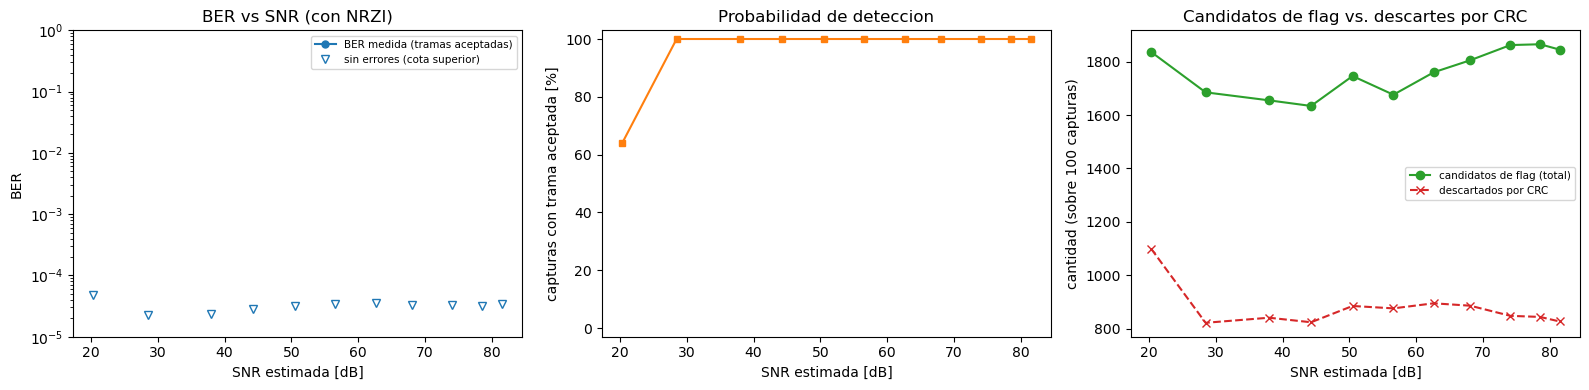


BER = 0 a partir de 20 dB de SNR estimada
Deteccion del 100% a partir de 28 dB

Total candidatos de flag: 19369  |  total descartados por CRC: 9647


In [86]:
# ============================================================
# CELDA 4b — Barrido de amplitud: SNR real vs. deteccion, BER y descartes por CRC
# ============================================================
import matplotlib.pyplot as plt

p_tx = np.array(payload_tx, dtype=np.uint8)

AMPLITUDES_REL = [0.001, 0.002, 0.005, 0.01, 0.02, 0.04, 0.08, 0.15, 0.3, 0.5, 0.7]
N_CAP_SNR = 100

AMPLITUD_ORIG = AMPLITUD
words_orig = words_tx.copy()

tx_stop(sock)
iq_ruido = read_adc(sock, N_RX)
P_ruido = float(np.mean(np.abs(iq_ruido - np.mean(iq_ruido))**2))
print(f"Piso de ruido medido (TX apagado): P_ruido = {P_ruido:.3e}\n")

barr = []
for amp_rel in AMPLITUDES_REL:
    AMPLITUD = amp_rel * AMPLITUD_ORIG
    words_amp, _, _, _ = construir_buffer_dac(bits_trama)
    tx_load_and_start(sock, words_amp)

    det = errs = nbits = nfr = 0
    candidatos_flag = descartadas_crc = 0
    p_sen = []
    for s in range(N_CAP_SNR):
        iq = read_adc(sock, N_RX)
        m = np.abs(iq); activo = m > 0.5 * np.max(m)
        if np.any(activo):
            p_sen.append(float(np.mean(np.abs(iq[activo] - np.mean(iq))**2)))
        rx_ = RxGmskCiego((iq / (np.max(np.abs(iq)) + 1e-12)).astype(np.complex64),
                          SPS_RX)
        rx_.run()
        pls = rx_.payloads()
        det += bool(pls)
        candidatos_flag += rx_.n_candidatos_flag
        descartadas_crc += rx_.n_descartadas_crc
        for pl in pls:
            nfr += 1
            errs += int(np.sum(pl != p_tx))
            nbits += N_PAYLOAD

    snr_est = 10*np.log10(np.mean(p_sen)/P_ruido) if p_sen else np.nan
    barr.append((snr_est, det/N_CAP_SNR, errs/nbits if nbits else np.nan, nfr, nbits,
                 candidatos_flag, descartadas_crc))
    print(f"  amplitud x{amp_rel:.2f}  SNR est. {snr_est:5.1f} dB: "
          f"deteccion {det:2d}/{N_CAP_SNR}, {nfr:2d} tramas aceptadas, "
          f"{errs:4d} errores en {nbits:5d} bits  |  "
          f"{candidatos_flag} candidatos de flag, {descartadas_crc} descartados por CRC")

AMPLITUD = AMPLITUD_ORIG
tx_load_and_start(sock, words_orig)

snr_v = np.array([b[0] for b in barr]); pdet = np.array([b[1] for b in barr])
ber_v = np.array([b[2] for b in barr]); nb_v = np.array([b[4] for b in barr])
cand_v = np.array([b[5] for b in barr]); desc_v = np.array([b[6] for b in barr])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
m = ber_v > 0
ax[0].semilogy(snr_v[m], ber_v[m], 'o-', ms=5, label='BER medida (tramas aceptadas)')
cota = 1.0/np.maximum(nb_v, 1)
ax[0].semilogy(snr_v[~m], cota[~m], 'v', ms=6, color='C0', mfc='none',
               label='sin errores (cota superior)')
ax[0].set_xlabel('SNR estimada [dB]'); ax[0].set_ylabel('BER'); ax[0].set_ylim(1e-5, 1)
ax[0].set_title('BER vs SNR (con NRZI)')
ax[0].legend(fontsize=7.5)

ax[1].plot(snr_v, 100*pdet, 's-', ms=5, color='C1')
ax[1].set_xlabel('SNR estimada [dB]'); ax[1].set_ylabel('capturas con trama aceptada [%]')
ax[1].set_ylim(-3, 103); ax[1].set_title('Probabilidad de deteccion')

ax[2].plot(snr_v, cand_v, 'o-', color='C2', label='candidatos de flag (total)')
ax[2].plot(snr_v, desc_v, 'x--', color='C3', label='descartados por CRC')
ax[2].set_xlabel('SNR estimada [dB]'); ax[2].set_ylabel(f'cantidad (sobre {N_CAP_SNR} capturas)')
ax[2].set_title('Candidatos de flag vs. descartes por CRC')
ax[2].legend(fontsize=7.5)

plt.tight_layout()
plt.show()

sin_err = snr_v[[i for i, b in enumerate(barr) if b[4] > 0 and b[2] == 0]]
det100 = snr_v[pdet >= 1.0]
print(f"\nBER = 0 a partir de "
      f"{'%.0f' % sin_err.min() if sin_err.size else 'n/d'} dB de SNR estimada")
print(f"Deteccion del 100% a partir de "
      f"{'%.0f' % det100.min() if det100.size else 'n/d'} dB")
print(f"\nTotal candidatos de flag: {cand_v.sum()}  |  total descartados por CRC: {desc_v.sum()}")

In [87]:
# ============================================================
# CELDA 5 — Cierre
# ============================================================
tx_stop(sock)
sock.close()
print("TX detenido, conexion cerrada.")


TX detenido, conexion cerrada.
